In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import string
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, AutoModel, AutoModelForSeq2SeqLM, pipeline, AutoModelForMultipleChoice, Trainer, TrainingArguments, DefaultDataCollator
from sentence_transformers import SentenceTransformer, util
from collections import Counter
from nltk.corpus import stopwords
import nltk
import re
from peft import LoraConfig, get_peft_model, TaskType
from torch.nn.functional import softmax


!pip install datasets -q
!pip install transformers -q
!pip install sentence-transformers
!pip install peft accelerate


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 84.2 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.

In [2]:
sample_submission = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")
sample_submission
# sample_submission.to_csv("submission.csv", index = False)

,ID,Prediction
0,1,A B C
1,2,A B C
2,3,A B C
3,4,A B C
4,5,A B C
...,...,...
495,496,A B C
496,497,A B C
497,498,A B C
498,499,A B C


In [3]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
train

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A
...,...,...,...,...,...,...,...,...
1995,1996,What is the piezoelectric strain coefficient f...,d = 1.9·10‑12 m/V,d = 3.1·10‑12 m/V,d = 4.2·10‑12 m/V,d = 2.5·10‑12 m/V,d = 5.8·10‑12 m/V,B
1996,1997,Identify the correct statement: What is the sy...,A device used to demonstrate a neuro-inspired ...,A device used to demonstrate a neuro-inspired ...,A device used to demonstrate a neuro-inspired ...,A device used to demonstrate a neuro-inspired ...,A device used to demonstrate a neuro-inspired ...,E
1997,1998,Determine the correct option: What does Earnsh...,A collection of point charges can be maintaine...,A collection of point charges can be maintaine...,A collection of point charges can be maintaine...,A collection of point charges cannot be mainta...,A collection of point charges can be maintaine...,D
1998,1999,Identify the correct statement: What is the re...,The atmosphere is a mechanism that is only inf...,"The atmosphere possesses both chaos and order,...",The atmosphere is a structure that is only inf...,The atmosphere is a completely chaotic mechani...,The atmosphere is a completely ordered structu...,B


In [4]:
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
test

,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...
...,...,...,...,...,...,...,...
495,496,What are the constituents of cold dark matter?,"They are unknown, but possibilities include la...",They are known to be black holes and Preon stars.,They are only MACHOs.,They are clusters of brown dwarfs.,They are new particles such as RAMBOs.
496,497,Pick the best possible answer: What is a plane...,A framework of planets that are all located in...,A mechanism of planets that are all the same s...,Any set of gravitationally bound non-stellar o...,A mechanism of planets that are all located in...,A structure of planets that are all made of gas.
497,498,Pick the best possible answer: What is magneti...,Magnetic susceptibility is a measure of how mu...,Magnetic susceptibility is a measure of how mu...,Magnetic susceptibility is a measure of how mu...,Magnetic susceptibility is a measure of how mu...,Magnetic susceptibility is a measure of how mu...
498,499,Determine the correct option: What is the evid...,The Milky Way galaxy has a supermassive black ...,The Milky Way galaxy has a supermassive black ...,The Milky Way galaxy has a supermassive black ...,The Milky Way galaxy has a supermassive black ...,The star S2 follows an elliptical orbit with a...


In [5]:
print(train.shape)
print(test.shape)

print(train.columns)

(2000, 8)
(500, 7)
Index(['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer'], dtype='object')


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [7]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      500 non-null    int64 
 1   prompt  500 non-null    object
 2   A       500 non-null    object
 3   B       500 non-null    object
 4   C       500 non-null    object
 5   D       500 non-null    object
 6   E       500 non-null    object
dtypes: int64(1), object(6)
memory usage: 27.5+ KB


In [8]:

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

# Combine all text
all_text = " ".join(
    (
        train["prompt"] + " " +
        train["A"] + " " +
        train["B"] + " " +
        train["C"] + " " +
        train["D"] + " " +
        train["E"]
    ).astype(str)
)

# Clean text
cleaned = re.sub(r"[^a-zA-Z\s]", "", all_text.lower())

words = cleaned.split()

# Remove only NLTK stopwords
filtered_words = [
    word for word in words
    if word not in stop_words
]

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
word_counts = Counter(filtered_words)

freq_df = (
    pd.DataFrame(
        word_counts.items(),
        columns=["Word","Frequency"]
    )
    .sort_values(
        by="Frequency",
        ascending=False
    )
)

freq_df.head(100)

,Word,Frequency
103,used,1307
100,correct,1175
439,light,967
109,energy,818
510,symmetry,799
...,...,...
412,metal,273
857,applied,269
1017,universe,267
416,cause,261


In [10]:
dataset_stopwords = freq_df.head(30)

print(dataset_stopwords)

            Word  Frequency
103         used       1307
100      correct       1175
439        light        967
109       energy        818
510     symmetry        799
160    following        746
313  temperature        722
353      measure        701
572         mass        692
787     rotation        692
44        effect        676
8           time        651
112        field        638
321       object        616
276        given        610
101       option        608
3         answer        608
48         based        607
198        space        593
190      density        593
235        black        566
584          one        564
573        force        550
223       matter        549
156         axis        533
99     determine        530
450      surface        523
130          two        507
66      particle        507
142    different        487


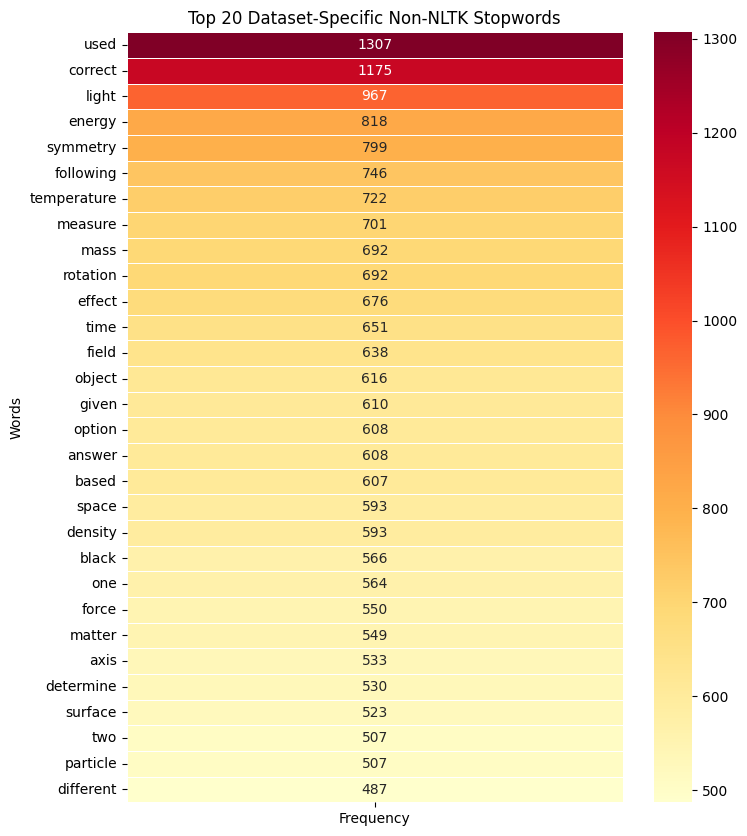

In [11]:

top20 = dataset_stopwords.set_index("Word")

plt.figure(figsize=(8,10))

sns.heatmap(
    top20,
    annot=True,
    cmap="YlOrRd",
    fmt="d",
    linewidths=0.5
)

plt.title("Top 20 Dataset-Specific Non-NLTK Stopwords")

plt.ylabel("Words")

plt.show()

/tmp/ipykernel_58/3470944140.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


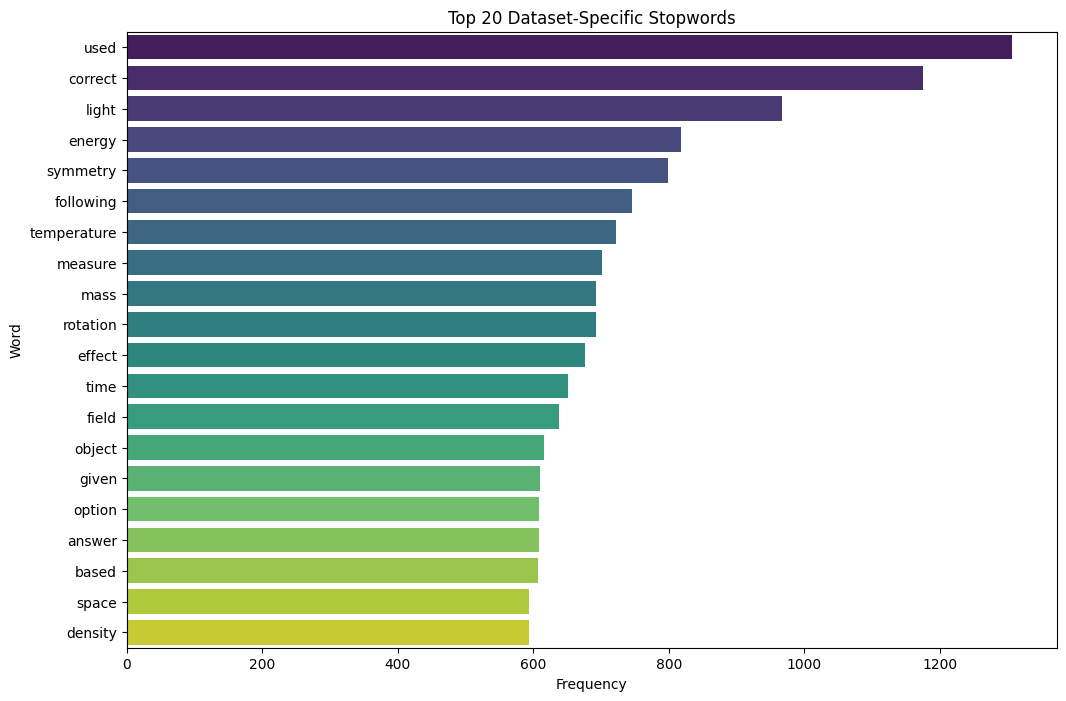

In [12]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=dataset_stopwords.head(20),
    x="Frequency",
    y="Word",
    palette="viridis"
)

plt.title("Top 20 Dataset-Specific Stopwords")

plt.xlabel("Frequency")

plt.ylabel("Word")

plt.show()

# Milestone 1


Milestone 1 Question 1

Calculate the frequency distribution of the correct  answer  (A, B, C, D, E) in train.csv. Based on your counts, what is the sum of the occurrences of the most frequent option and the least frequent option?  

In [13]:
# Milestone 1 Q1
freq = train["answer"].value_counts()

print(freq)

answer_q1 = freq.max() + freq.min()

print("M1Q1 Answer =", answer_q1)

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64
M1Q1 Answer = 814


Milestone 1 Question 2

After converting the prompt column to lowercase and removing all standard punctuation characters (using Python's string.punctuation), split the text by whitespace. What is the total number of unique words (vocabulary size) across the entire cleaned prompt column of train.csv?  

In [14]:
# Milestone 1 Q2

all_prompts = " ".join(
    train["prompt"].astype(str)
)

cleaned = (
    all_prompts
    .lower()
    .translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )
)

words = cleaned.split()

vocab_size = len(set(words))

print("M1Q2 Answer =", vocab_size)

M1Q2 Answer = 859


Milestone 1 Question 3

Using the cleaned prompt from Row ID 1, filter out the standard English stop words using sklearn.feature_extraction.text.ENGLISH_STOP_WORDS. How many words are left in the prompt for Row ID 1 after filtering?  

In [15]:
# Milestone 1 Q3
prompt = train.loc[0, "prompt"]

cleaned = (
    prompt.lower()
    .translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )
)

tokens = cleaned.split()

filtered_tokens = [
    word
    for word in tokens
    if word not in ENGLISH_STOP_WORDS
]

print(filtered_tokens)
print("M1Q3 Answer =", len(filtered_tokens))

['pick', 'best', 'possible', 'answer', 'martin', 'heideggers', 'view', 'relationship', 'time', 'human', 'existence', 'listed', 'options']
M1Q3 Answer = 13


Milestone 1 Question 4 

Fit a default TfidfVectorizer(stop_words='english') on a list containing all the combined text of the prompts and options in train.csv. What is the exact total number of feature columns (vocabulary size) generated by the vectorizer?  

In [16]:
# Milestone 1 Q4
combined_text = []

for _, row in train.iterrows():

    text = (
        str(row["prompt"]) + " "
        + str(row["A"]) + " "
        + str(row["B"]) + " "
        + str(row["C"]) + " "
        + str(row["D"]) + " "
        + str(row["E"])
    )

    combined_text.append(text)

vectorizer = TfidfVectorizer(
    stop_words="english"
)

X = vectorizer.fit_transform(
    combined_text
)

print("M1Q4 Answer =", X.shape[1])

M1Q4 Answer = 2762


Milestone 1 Question 5

Using the TF-IDF vectorizer fitted in Question 3, calculate the cosine similarity between the prompt and option A strictly for Row ID 1. What is the resulting similarity score? (Round to 4 decimal places). 

In [17]:
# Milestone 1 Q5
prompt = train.loc[0, "prompt"]

option_a = train.loc[0, "A"]

prompt_vec = vectorizer.transform(
    [prompt]
)

option_vec = vectorizer.transform(
    [option_a]
)

similarity = cosine_similarity(
    prompt_vec,
    option_vec
)[0][0]

print(
    "M1Q5 Answer =",
    round(similarity, 4)
)

M1Q5 Answer = 0.272


Milestone 1 Question 6

Expand the logic from Question 4: For every row in train.csv, calculate the cosine similarity between the prompt and each of its 5 options .  Then calculate the percentage of instances where the option with the highest cosine similarity matches the correct answer.  

In [18]:
# Milestone 1 Q6

correct = 0

for _, row in train.iterrows():

    prompt = row["prompt"]

    options = {
        "A": row["A"],
        "B": row["B"],
        "C": row["C"],
        "D": row["D"],
        "E": row["E"]
    }

    prompt_vec = vectorizer.transform(
        [prompt]
    )

    similarities = {}

    for option_name, option_text in options.items():

        option_vec = vectorizer.transform(
            [option_text]
        )

        sim = cosine_similarity(
            prompt_vec,
            option_vec
        )[0][0]

        similarities[option_name] = sim

    prediction = max(
        similarities,
        key=similarities.get
    )

    if prediction == row["answer"]:
        correct += 1

accuracy = (
    correct
    / len(train)
) * 100

print(
    "Q6 Answer =",
    round(accuracy, 2)
)

Q6 Answer = 13.55


Milestone 1 Question 7

If the ground truth answer for a question is C, what is the MAP@3 score if a model predicts C A B ?  


ANSWER: 
Ground Truth Answer: C

Predicted Ranking: [C, A, B]

The correct answer appears at Rank 1.

For a single relevant answer, Average Precision at 3 (AP@3) is calculated as:
[
AP@3 = 1/ Rank
]

Therefore,
[
AP@3 = 1/1 = 1.0
]

Final Answer: 1.0

Milestone 1 Question 8

If the ground truth answer for a question is  B, what is the MAP@3 score if a model predicts D B E?  


Answer:

Ground Truth Answer: **B**


Predicted Ranking: **[D, B, E]**


The correct answer appears at **Rank 2**.


For a single relevant answer, Average Precision at 3 (AP@3) is calculated as:


[
AP@3 = 1/Rank
]


Therefore,

[
AP@3 = 1/2 = 0.5
]


**Final Answer: 0.5**


Milestone 1 Question 9 

The Majority Class Baseline: Find the most frequent correct answer in the training set (using your data from Q1). Make a static prediction for every single row where that most frequent answer is your 1st guess, followed by the second most frequent, and then the third most frequent. What is the overall MAP@3 score of this "Majority Class" baseline on train.csv?

In [19]:
# Milestone 1 Q9

freq = train["answer"].value_counts()

print(freq)

# Top 3 most frequent answers
top3 = list(freq.index[:3])

print("Top 3 answers:", top3)

def map3(actual, preds):
    for i, p in enumerate(preds):
        if p == actual:
            return 1/(i+1)
    return 0

scores = []

for ans in train["answer"]:
    scores.append(map3(ans, top3))

baseline_map3 = sum(scores) / len(scores)

print("MAP@3 =", baseline_map3)
print("Rounded =", round(baseline_map3, 4))

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64
Top 3 answers: ['B', 'C', 'A']
MAP@3 = 0.42125
Rounded = 0.4213


Milestone 1 Question 10

The TF-IDF Pipeline: Build a basic pipeline that evaluates every row in train.csv. For each row, calculate the TF-IDF cosine similarity between the prompt and each of the 5 options. Sort these options from highest similarity to lowest to form your top 3 predictions. What is the final average MAP@3 score of this TF-IDF pipeline across the entire training set? 

In [20]:
# Milestone 1 Q10

combined_text = (
    train["prompt"] + " " +
    train["A"] + " " +
    train["B"] + " " +
    train["C"] + " " +
    train["D"] + " " +
    train["E"]
)

vectorizer = TfidfVectorizer(stop_words="english")
vectorizer.fit(combined_text)

TfidfVectorizer(stop_words='english')

In [21]:
# Milestone 1 Q10

def map3(actual, preds):
    for i, p in enumerate(preds):
        if p == actual:
            return 1/(i+1)
    return 0

scores = []
tfidf_predictions = []

for _, row in train.iterrows():

    prompt_vec = vectorizer.transform([row["prompt"]])

    similarities = {}

    for option in ["A", "B", "C", "D", "E"]:

        option_vec = vectorizer.transform([row[option]])

        sim = cosine_similarity(
            prompt_vec,
            option_vec
        )[0][0]

        similarities[option] = sim

    ranked_options = sorted(
        similarities,
        key=similarities.get,
        reverse=True
    )

    top3 = ranked_options[:3]
    
    tfidf_predictions.append(top3)

    score = map3(
        row["answer"],
        top3
    )

    scores.append(score)

final_map3 = sum(scores) / len(scores)

print("MAP@3 =", final_map3)
print("Rounded =", round(final_map3, 4))

MAP@3 = 0.2961666666666667
Rounded = 0.2962


In [22]:
print(len(tfidf_predictions))
print(tfidf_predictions[:5])

2000
[['C', 'D', 'B'], ['C', 'B', 'A'], ['A', 'B', 'C'], ['C', 'D', 'B'], ['D', 'E', 'B']]


# Milestone 2


Milestone 2 Question 1

Load train.csv using the Hugging Face datasets library (do not use pandas). Use the .map() function to create a new column called combined_text that concatenates the prompt and A columns with a space in between. E.g., prompt_text A_text. What is the exact character length (total number of string characters using Python's len() function, NOT the number of tokens) of the combined_text string for the row at index 51? Note: We follow zero-indexing here.

In [23]:
# Milestone 2 Q1
train_dataset = load_dataset(
    "csv",
    data_files="/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")["train"]

Generating train split: 0 examples [00:00, ? examples/s]

In [24]:
# Milestone 2 Q1
def create_combined_text(example):
    example["combined_text"] = example["prompt"] + " " + example["A"]
    return example

In [25]:
# Milestone 2 Q1
train_dataset = train_dataset.map(create_combined_text)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [26]:
# Milestone 2 Q1
answer = len(train_dataset[51]["combined_text"])

print("Answer:", answer)

Answer: 614


In [27]:
print(train_dataset[1])

{'id': 2, 'prompt': 'What is accelerator-based light-ion fusion?', 'A': 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fusion can be observed with as little as 10 kV between the electrodes.', 'B': 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fusion can be observed with as little as 10 kV between the electrodes.', 'C': 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce

Milestone 2 Question 2

Initialize the bert-base-uncased tokenizer. Look at the tokenizer's configuration properties: what is the exact total vocabulary size (the maximum number of unique subword tokens the model knows) hardcoded into this tokenizer?  


In [28]:
# Milestone 2 Q2

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

print("Vocabulary Size =", tokenizer.vocab_size)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocabulary Size = 30522


Milestone 2 Question 3

Transformers rely on special tokens to understand sentence boundaries. Using the bert-base-uncased tokenizer from the previous step, extract the exact integer ID assigned to the [SEP] (Separator) token.

In [29]:
# Milestone 2 Q3

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
print(tokenizer.sep_token)
print(tokenizer.sep_token_id)

[SEP]
102


Milestone 2 Question 4

Using the bert-base-uncased tokenizer, tokenize the entire prompt column of the train dataset simultaneously. Set padding='max_length', truncation=True, max_length=128, and return_tensors='pt' (PyTorch tensors). 
What is the exact geometric shape (dimensions) of the resulting input_ids tensor?

In [30]:
# Milestone 2 Q4

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Convert the Hugging Face Column to a Python list
prompts = list(train_dataset["prompt"])

encoded = tokenizer(
    prompts,
    padding="max_length",
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

print(encoded["input_ids"].shape)

torch.Size([2000, 128])


In [31]:
print(type(prompts))
print(type(prompts[0]))
print(prompts[0])

<class 'list'>
<class 'str'>
Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.


Milestone 2 Question 5

BERT/RoBERTa Architecture & Attention Mechanisms

A standard bert-base-uncased model has a hidden embedding size of 768 dimensions and uses exactly 12 attention heads in each layer. 
In Transformer architecture, the hidden size is divided equally among the attention heads. What is the exact dimensionality (size) of each individual attention head?  

Milestone 2 Q5 Solution


In the BERT Base architecture, the hidden embedding size is 768 and the model uses 12 attention heads. Since the hidden representation is divided equally among all attention heads, the size of each attention head is calculated as:

Head Dimension = Hidden Size / Number of Heads = 768 / 12 = 64

Therefore, each attention head has a dimensionality of 64.

Milestone 2 Question 6

Load the bert-base-uncased model using AutoModel.from_pretrained(). Tokenize the prompt from row ID 0 using the tokenizer's default settings (do not apply any manual padding or truncation). Pass this tokenized input through the model. Look at the output object. 
What is the exact shape of the last_hidden_state tensor returned? 
Note: We follow zero-indexing here.

In [32]:
# Milestone 2  Q6

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Load BERT model
model = AutoModel.from_pretrained("bert-base-uncased")

# First prompt (row ID 0)
text = train_dataset[0]["prompt"]

print(text)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.


In [33]:
inputs = tokenizer(
    text,
    return_tensors="pt"
)
inputs

{'input_ids': tensor([[  101,  4060,  1996,  2190,  2825,  3437,  1024,  2054,  2003,  3235,
          2002,  5178, 13327,  1005,  1055,  3193,  2006,  1996,  3276,  2090,
          2051,  1998,  2529,  4598,  1029,  2426,  1996,  3205,  7047,  1012,
           102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1]])}

In [34]:
outputs = model(**inputs)
outputs

BaseModelOutputWithPoolingAndCrossAttentions(last_hidden_state=tensor([[[-0.4677, -0.0754, -0.2019,  ..., -0.0726,  0.6572,  0.5506],
         [-0.3783, -0.0790, -0.0184,  ...,  0.0546,  0.4026,  0.1284],
         [-1.1947, -0.7359,  0.2192,  ...,  0.6096,  1.0815,  0.1809],
         ...,
         [-0.2402, -0.4758, -0.2410,  ...,  0.0362,  0.9403,  0.3462],
         [-0.3097, -0.7685, -0.4455,  ...,  0.3885,  0.8686, -0.3180],
         [ 0.6300,  0.2221, -0.1082,  ...,  0.4051, -0.2192,  0.0341]]],
       grad_fn=<NativeLayerNormBackward0>), pooler_output=tensor([[-0.8721, -0.4912, -0.9036,  0.7628,  0.6580, -0.1722,  0.8342,  0.2401,
         -0.8083, -1.0000, -0.5096,  0.9392,  0.9778,  0.5440,  0.8579, -0.6980,
         -0.2626, -0.6476,  0.3560, -0.2397,  0.7059,  1.0000,  0.0933,  0.3548,
          0.4943,  0.9899, -0.7505,  0.8854,  0.9418,  0.6376, -0.5243,  0.2739,
         -0.9872, -0.2204, -0.8876, -0.9957,  0.4414, -0.7344,  0.0493, -0.0066,
         -0.8635,  0.2816,  1.00

In [35]:
print(outputs.last_hidden_state.shape)

torch.Size([1, 31, 768])


In [36]:
outputs.last_hidden_state

tensor([[[-0.4677, -0.0754, -0.2019,  ..., -0.0726,  0.6572,  0.5506],
         [-0.3783, -0.0790, -0.0184,  ...,  0.0546,  0.4026,  0.1284],
         [-1.1947, -0.7359,  0.2192,  ...,  0.6096,  1.0815,  0.1809],
         ...,
         [-0.2402, -0.4758, -0.2410,  ...,  0.0362,  0.9403,  0.3462],
         [-0.3097, -0.7685, -0.4455,  ...,  0.3885,  0.8686, -0.3180],
         [ 0.6300,  0.2221, -0.1082,  ...,  0.4051, -0.2192,  0.0341]]],
       grad_fn=<NativeLayerNormBackward0>)

Milestone 2 Question 7

Using the last_hidden_state tensor from the previous question, extract the embedding vector representing the [CLS] token (which is always the token at index 0). What is the sum of the first 5 float values in this [CLS] vector? (Round your answer to 4 decimal places). 

In [37]:
# Milestone 2 Q7

cls_embedding = outputs.last_hidden_state[0, 0, :]

answer = cls_embedding[:5].sum().item()

print(round(answer, 4))

-1.2001


Milestone 2 Question 8

Load bert-base-uncased with the parameter output_attentions=True. Tokenize the exact string "Light-ion fusion is a technique." (ensuring you set return_tensors='pt') and pass it through the model. Extract the attention matrix for the last layer (index -1) and the first attention head (head index 0). 
What is the exact attention weight (a float value) that the [CLS] token (token index 0) pays to the word fusion (you will need to find the specific token index for fusion in the input_ids)? (Round your answer to 4 decimal places). 

In [38]:
# Milestone 2 Q8

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

model = AutoModel.from_pretrained(
    "bert-base-uncased",
    output_attentions=True
)

sentence = "Light-ion fusion is a technique."

inputs = tokenizer(
    sentence,
    return_tensors="pt"
)

outputs = model(**inputs)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

print("Tokens:")
for i, token in enumerate(tokens):
    print(i, token)

attention = outputs.attentions[-1][0][0]

fusion_index = tokens.index("fusion")

print("\nFusion index:", fusion_index)

weight = attention[0, fusion_index].item()

print("Attention weight:", round(weight, 4))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Tokens:
0 [CLS]
1 light
2 -
3 ion
4 fusion
5 is
6 a
7 technique
8 .
9 [SEP]

Fusion index: 4
Attention weight: 0.1025


Milestone 2 Question 9

Initialize the sentence-transformers/all-MiniLM-L6-v2 model. Use the model's .encode() method to generate embeddings for both the prompt and Option B for row ID 0. Calculate the cosine similarity between these two vectors specifically using the sentence_transformers.util.cos_sim() function. What is the resulting similarity score rounded to 4 decimal places? Note: We follow zero-indexing here.


In [39]:
# Milestone 2 Q9

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

prompt = train_dataset[0]["prompt"]
option_b = train_dataset[0]["B"]

prompt_embedding = model.encode(prompt, convert_to_tensor=True)
option_embedding = model.encode(option_b, convert_to_tensor=True)

similarity = util.cos_sim(prompt_embedding, option_embedding)

print("Cosine Similarity:", round(similarity.item(), 4))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Cosine Similarity: 0.7658


Milestone 2 Question 10

Build two complete ranking pipelines evaluating every row in train.csv.
Pipeline 1: Use the TF-IDF cosine similarity approach from Milestone 1.
Pipeline 2: Use the sentence-transformers/all-MiniLM-L6-v2 model to generate embeddings for the prompt and all five options. Rank options using cosine similarity to form Top-3 predictions.
First, what is the final MAP@3 score of the all-MiniLM-L6-v2 pipeline across the entire training set? 
Second, count the number of questions for which the correct answer is NOT present in the TF-IDF Top-3 predictions BUT IS present in the MiniLM Top-3 predictions. What is this exact resulting count? 


In [40]:
# Milestone 2 Q10

model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [41]:
# Milestone 2 Q10

def map3_score(true_answer, prediction):

    if true_answer == prediction[0]:
        return 1

    elif true_answer == prediction[1]:
        return 1/2

    elif true_answer == prediction[2]:
        return 1/3

    return 0

In [42]:
# Milestone 2 Q10

labels = ["A","B","C","D","E"]

mini_scores = []
mini_predictions = []

for row in train_dataset:

    prompt_embedding = model.encode(
        row["prompt"],
        convert_to_tensor=True
    )

    similarities = []

    for option in labels:

        option_embedding = model.encode(
            row[option],
            convert_to_tensor=True
        )

        score = util.cos_sim(
            prompt_embedding,
            option_embedding
        ).item()

        similarities.append(score)

    ranking = sorted(
        zip(labels, similarities),
        key=lambda x: x[1],
        reverse=True
    )

    top3 = [x[0] for x in ranking[:3]]

    mini_predictions.append(top3)

    mini_scores.append(
        map3_score(
            row["answer"],
            top3
        )
    )

print(len(mini_predictions))
print(sum(mini_scores)/len(mini_scores))

2000
0.4230833333333333


In [43]:
# Milestone 2 Q10

count = 0

for i,row in enumerate(train_dataset):

    answer = row["answer"]

    tfidf_top3 = tfidf_predictions[i]

    mini_top3 = mini_predictions[i]

    if (

        answer not in tfidf_top3

        and

        answer in mini_top3

    ):

        count += 1

print(count)

502


In [44]:
print("Train dataset:", len(train_dataset))
print("TF-IDF predictions:", len(tfidf_predictions))
print("MiniLM predictions:", len(mini_predictions))

Train dataset: 2000
TF-IDF predictions: 2000
MiniLM predictions: 2000


In [45]:
print("MiniLM MAP@3 =", round(sum(mini_scores)/len(mini_scores), 4))

MiniLM MAP@3 = 0.4231


Milestone 2 Q11

Zero-shot classification concepts 

Initialize the Hugging Face pipeline for "zero-shot-classification" (it will default to facebook/bart-large-mnli). For the prompt of the 2nd row (index 1), pass Options A, B, and C as the candidate_labels. What is the probability score given to the top-ranked option? (Round to 4 decimal places).


In [46]:
# Milestone 2 Q11

classifier = pipeline("zero-shot-classification")

prompt = train_dataset[1]["prompt"]

candidate_labels = [
    train_dataset[1]["A"],
    train_dataset[1]["B"],
    train_dataset[1]["C"]
]

result = classifier(
    prompt,
    candidate_labels=candidate_labels
)

print(result)

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'sequence': 'What is accelerator-based light-ion fusion?', 'labels': ['Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fusion can be observed with as little as 10 kV between the electrodes.', 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fusion can be observed with as little as 100 kV between the electrodes.', 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion

In [47]:
# Milestone Q11
print(result["scores"][0])
print(round(result["scores"][0], 4))

0.4574522376060486
0.4575


Milestone 2 Question 12

Run the exact same zero-shot classification as the previous question, but this time pass the argument multi_label=True. 
What is the absolute difference between the sum of the 3 probabilities in the previous question (which uses Softmax) and the sum of the 3 probabilities in this question (which uses independent Sigmoids)?

In [48]:
# Milestone 2 Q12

classifier = pipeline("zero-shot-classification")

prompt = train_dataset[1]["prompt"]

candidate_labels = [
    train_dataset[1]["A"],
    train_dataset[1]["B"],
    train_dataset[1]["C"]
]

result_softmax = classifier(
    prompt,
    candidate_labels=candidate_labels
)

print(result_softmax)

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

{'sequence': 'What is accelerator-based light-ion fusion?', 'labels': ['Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fusion can be observed with as little as 10 kV between the electrodes.', 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fusion can be observed with as little as 100 kV between the electrodes.', 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion

In [49]:
# Milestone 2 Q12

sum_softmax = sum(result_softmax["scores"])
print(sum_softmax)

0.9999999701976776


In [50]:
# Milestone 2 Q12

result_sigmoid = classifier(
    prompt,
    candidate_labels=candidate_labels,
    multi_label=True
)

print(result_sigmoid)

{'sequence': 'What is accelerator-based light-ion fusion?', 'labels': ['Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fusion can be observed with as little as 10 kV between the electrodes.', 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fusion can be observed with as little as 10 kV between the electrodes.', 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion 

In [51]:
# Milestone 2 Q12

sum_sigmoid = sum(result_sigmoid["scores"])

print(sum_sigmoid)

0.0005095975611766335


In [52]:
# Milestone 2 Q12

difference = abs(sum_softmax - sum_sigmoid)

print(difference)
print(round(difference, 4))

0.999490372636501
0.9995


Milestone 2 Question 13

Let's try Generative AI instead of Classification. 

Load a Small Language Model like google/flan-t5-small using the Hugging Face pipeline("text2text-generation"). Construct the following exact string for row index 0: "Question: [prompt]. Is the correct answer A: [A] or B: [B]? Answer with just the letter A or B." 
Pass this string to the pipeline, setting max_new_tokens=5. What is the exact string output returned by the model? 


In [53]:
# Milestone 2 Q13

tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-small")
model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [54]:
# Milestone 2 Q13

row = train_dataset[0]

prompt = (
    f"Question: {row['prompt']}. "
    f"Is the correct answer A: {row['A']} or B: {row['B']}? "
    f"Answer with just the letter A or B."
)

inputs = tokenizer(prompt, return_tensors="pt")

outputs = model.generate(
    **inputs,
    max_new_tokens=5
)

generated = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(repr(generated))

'B'


# Milestone 3


Milestone 3 setup (run first, before answering any questions)
Run this code in a code cell
 before answering any of the question. This will create your knowledge 
base and the FAISS index for this milestone.

!pip install faiss-cpu #install FAISS

import pandas as pd 
import numpy as np 
import faiss 
from sentence_transformers import SentenceTransformer, CrossEncoder 
from transformers import AutoTokenizer, pipeline 
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.metrics.pairwise import cosine_similarity 

train = pd.read_csv('train.csv') 

print("Creating nowledge base)
kb = [] 
for idx, row in train.iterrows(): 
    correct_letter = row['answer'] 
    kb.append(str(row[correct_letter])) 

print("Loading embedding model and creating index") 
model = SentenceTransformer('all-MiniLM-L6-v2') 
kb_embeddings = model.encode(kb, show_progress_bar=False) 
index = faiss.IndexFlatL2(kb_embeddings.shape[1]) 
index.add(kb_embeddings)

print("Knowledge base successfully created")


Zero-shot classifier for Q1, Q2, Q6
zs = pipeline("zero-shot-classification", model="facebook/bart-large-mnli") 
row_150 = train.iloc[150] 
prompt_150 = str(row_150['prompt']) 
labels_150 = [str(row_150['A']), str(row_150['B']), str(row_150['C']), str(row_150['D']), str(row_150['E'])] 
ans_150 = str(row_150[row_150['answer']])

 Milestone 3 Question 1

 
Q1. Run the zero-shot classifier on facebook/bart-large-mnli on prompt for the row index 150. Pass the 5 options (A-E) candidate_labels. What is the predicted probability score assigned to the ground-truth correct option (option in the answer column)? (Round to 3 decimal points)

In [55]:
# Milestone 3 Q1

!pip install faiss-cpu #install FAISS

import pandas as pd 
import numpy as np 
import faiss 
from sentence_transformers import SentenceTransformer, CrossEncoder 
from transformers import AutoTokenizer, pipeline 
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.metrics.pairwise import cosine_similarity 

train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv') 

print("Creating nowledge base")
kb = [] 
for idx, row in train.iterrows(): 
    correct_letter = row['answer'] 
    kb.append(str(row[correct_letter])) 

print("Loading embedding model and creating index") 
model = SentenceTransformer('all-MiniLM-L6-v2') 
kb_embeddings = model.encode(kb, show_progress_bar=False) 
index = faiss.IndexFlatL2(kb_embeddings.shape[1]) 
index.add(kb_embeddings)

print("Knowledge base successfully created")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 75.6 MB/s eta 0:00:00:00:0100:01
Creating nowledge base
Loading embedding model and creating index


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Knowledge base successfully created


In [56]:
# Milestone 3 Q1
zs = pipeline("zero-shot-classification", model="facebook/bart-large-mnli") 
row_150 = train.iloc[150] 
prompt_150 = str(row_150['prompt']) 
labels_150 = [str(row_150['A']), str(row_150['B']), str(row_150['C']), str(row_150['D']), str(row_150['E'])] 
ans_150 = str(row_150[row_150['answer']])

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [57]:

# Milestone 3 Q1

result = zs(
    prompt_150,
    candidate_labels=labels_150
)

print(result)

{'sequence': 'Select the most accurate option: What is the butterfly effect, as defined by Lorenz in his book "The Essence of Chaos"? based on the given context.', 'labels': ['The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical framework can cause significant distinctions in subsequent states, as defined by Lorenz in his book "The Essence of Chaos."', 'The butterfly effect is the phenomenon that a large change in the initial conditions of a dynamical mechanism can cause significant distinctions in subsequent states, as defined by Lorenz in his book "The Essence of Chaos."', 'The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical mechanism can cause subsequent states to differ greatly from the states that would have followed without the alteration, as defined by Einstein in his book "The concept of Relativity."', 'The butterfly effect is the phenomenon that a small change in the initial conditio

In [58]:
# Milestone 3 Q1
print("Ground Truth:", ans_150)

correct_score = result["scores"][
    result["labels"].index(ans_150)
]

print("Correct option probability:", correct_score)
print("Rounded:", round(correct_score, 3))

Ground Truth: The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical framework can cause significant distinctions in subsequent states, as defined by Lorenz in his book "The Essence of Chaos."
Correct option probability: 0.38441911339759827
Rounded: 0.384


Milestone 3 Question 2


Q2. Embed the prompt for row index 150 using all-MiniLM-L6-v2. Query your FAISS index to retrieve the top k=10 most similar documents. At what exact rank (1 through 10) did FAISS place the true correct document (which is the document originally located at index 150 in the KB)?

In [59]:
# Milestone 3 Q2

query_embedding = model.encode([prompt_150], show_progress_bar=False)

k = 10
distances, retrieved_indices = index.search(query_embedding, k)

print("Retrieved Indices:")
print(retrieved_indices[0])

Retrieved Indices:
[ 663 1701 1269 1532  576  847 1693 1906  168  150]


In [60]:
# Milestone 3 Q2

retrieved_list = retrieved_indices[0].tolist()

print(retrieved_list)

rank = retrieved_list.index(150) + 1

print("Rank of true document:", rank)

[663, 1701, 1269, 1532, 576, 847, 1693, 1906, 168, 150]
Rank of true document: 10


Milestone 3 Question 3

Concept: The Two-Stage Pipeline (Reranking & Cross-Encoders)
In Question 2, you saw that our FAISS database did not put the true document at rank #1. Why? Because FAISS uses Bi-encoder. 
A Bi-encoder embeds the question and the document separately and just compares the distance (Cosine Similarity). They are fast and allows you to search millions of documents but often miss semantic context. 

To fix this we use a 2 stage pipeline:
1. Retrieval: Use a bi-encoder with FAISS to quickly get the top k possible chunks/documents.
2. Reranking: Use a Cross-Encoder to deeply evaluate those top candidates and sort them based on highest semantic similarity.

A Cross-Encoder passes the Question and the Document into the Transformer network at the exact same time. The Attention mechanism can directly compare the words in the question to the words in the document, resulting in a highly accurate relevance score.

For this we part the prompt and the context and ask it to predict a score.

Cross Encoders (Hugging Face)

Milestone 3 Question 3

Code to use a Cross-Encoder
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
docs_10 = [kb[i] for i in retrieved_indices] #Get the top 10 chunks
pairs = [[prompt_150, doc] for doc in docs_10] #Create prompt-context pairs
ce_scores = cross_encoder.predict(pairs) # Get the score of each pair

Milestone 3 Question 3

Q3. Take the top 10 documents retrieved by FAISS in the previous question. Load cross-encoder/ms-marco-MiniLM-L-6-v2. Score the prompt against these 10 documents and sort them by the cross-encoder's score. At what exact rank (1 through 10) does the Cross-Encoder place the true correct document?

In [61]:
# Milestone 3 Q3

from sentence_transformers import CrossEncoder

# Load CrossEncoder
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

# Top-10 documents retrieved in Q2
docs_10 = [kb[i] for i in retrieved_indices[0]]

# Create (query, document) pairs
pairs = [[prompt_150, doc] for doc in docs_10]

# Predict relevance scores
ce_scores = cross_encoder.predict(pairs)

# Sort by descending score
reranked = sorted(
    zip(retrieved_indices[0], ce_scores),
    key=lambda x: x[1],
    reverse=True
)

print("Reranked Results:")
for rank, (idx, score) in enumerate(reranked, start=1):
    print(f"Rank {rank}: Index={idx}, Score={score:.4f}")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Reranked Results:
Rank 1: Index=150, Score=4.7585
Rank 2: Index=847, Score=4.7526
Rank 3: Index=1693, Score=4.7526
Rank 4: Index=1906, Score=4.7526
Rank 5: Index=1269, Score=4.7375
Rank 6: Index=1532, Score=4.7375
Rank 7: Index=168, Score=4.7072
Rank 8: Index=576, Score=4.6870
Rank 9: Index=663, Score=4.6602
Rank 10: Index=1701, Score=4.6602


In [62]:
# Milestone 3 Q3
true_rank = None

for rank, (idx, score) in enumerate(reranked, start=1):
    if idx == 150:
        true_rank = rank
        break

print("True document rank:", true_rank)

True document rank: 1


Milestone 3 Question 4

Q4. Retrieve the top k=5 documents for the prompt at row index 42. Concatenate them with a single space between each. Create a string: "Context: [concatenated_docs] Question: [prompt]". Tokenize this string using the bert-base-uncased tokenizer (without truncation). Exactly how many total tokens does this generate? 

In [63]:
# Milestone 3 Q4

# BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Row 42
row_42 = train.iloc[42]
prompt_42 = str(row_42["prompt"])

# Embed the prompt
query_embedding = model.encode([prompt_42], show_progress_bar=False)

# Retrieve top-5 documents from FAISS
D, I = index.search(query_embedding.astype("float32"), 5)

# Get the retrieved documents
docs_5 = [kb[i] for i in I[0]]

# Concatenate with a single space
concatenated_docs = " ".join(docs_5)

# Create the exact string
text = f"Context: {concatenated_docs} Question: {prompt_42}"

# Tokenize WITHOUT truncation
tokens = tokenizer(
    text,
    truncation=False
)

# Total number of tokens
print("Total tokens:", len(tokens["input_ids"]))

Total tokens: 216


In [64]:
# Milestone 3 Q4
print("Total tokens:", len(tokens["input_ids"]))

Total tokens: 216


Milestone 3 Question 5

Q5. Retrieve the exact true document for row index 150 from your KB. Create a RAG string: "Context: [true_document] Question: [prompt]". Run the same zero-shot classification from Question 1 on this augmented string. What is the new predicted probability score of the ground-truth correct option? (Round to 3 decimal places). 

In [65]:
# Milestone 3 Q5

# Row 150
row_150 = train.iloc[150]

prompt_150 = str(row_150["prompt"])

labels_150 = [
    str(row_150["A"]),
    str(row_150["B"]),
    str(row_150["C"]),
    str(row_150["D"]),
    str(row_150["E"])
]

correct_letter = row_150["answer"]
correct_option = str(row_150[correct_letter])

# Retrieve the TRUE document from the KB
true_document = kb[150]

# Create the RAG prompt
rag_prompt = f"Context: {true_document} Question: {prompt_150}"

# Run the zero-shot classifier
result = zs(
    rag_prompt,
    candidate_labels=labels_150
)

print(result)

{'sequence': 'Context: The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical framework can cause significant distinctions in subsequent states, as defined by Lorenz in his book "The Essence of Chaos." Question: Select the most accurate option: What is the butterfly effect, as defined by Lorenz in his book "The Essence of Chaos"? based on the given context.', 'labels': ['The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical framework can cause significant distinctions in subsequent states, as defined by Lorenz in his book "The Essence of Chaos."', 'The butterfly effect is the phenomenon that a large change in the initial conditions of a dynamical mechanism can cause significant distinctions in subsequent states, as defined by Lorenz in his book "The Essence of Chaos."', 'The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical structure has no effect on 

In [66]:
# Milestone 3 Q5
score = dict(zip(result["labels"], result["scores"]))[correct_option]

print("Ground truth score:", score)
print("Rounded:", round(score, 3))

Ground truth score: 0.9894258379936218
Rounded: 0.989


Milestone 3 Question 6

Concept: The Danger of Bad Retrieval (Adversarial RAG) 
The golden rule of Retrieval-Augmented Generation is “Garbage In, Garbage Out.” An LLM places immense trust in the external context you inject into its prompt. If your vector database performs poorly and retrieves an irrelevant or incorrect document, the model will often abandon its own internal reasoning and confidently generate the wrong answer based on that bad data. We do the reranking and constricting the number of chunks that we give to the model for the same reason.




Q6. What happens if your vector database retrieves the wrong information? Take the prompt for row index 150. Manually force the context to be the document located at KB index 999 (a completely unrelated fact). Run the zero-shot classifier on this "Adversarial RAG" string. What is the probability of the correct option now? (Round to 3 decimal places).

In [67]:
# Milestone 3 Q6

# Row 150
row_150 = train.iloc[150]

prompt_150 = str(row_150["prompt"])

labels_150 = [
    str(row_150["A"]),
    str(row_150["B"]),
    str(row_150["C"]),
    str(row_150["D"]),
    str(row_150["E"])
]

correct_letter = row_150["answer"]
correct_option = str(row_150[correct_letter])

# Use an unrelated document (Adversarial RAG)
wrong_document = kb[999]

adversarial_prompt = (
    f"Context: {wrong_document} "
    f"Question: {prompt_150}"
)

result = zs(
    adversarial_prompt,
    candidate_labels=labels_150
)

print(result)

{'sequence': 'Context: A thought experiment in which a demon guards a microscopic trapdoor in a wall separating two parts of a container filled with the same gas at equal temperatures. The demon selectively allows faster-than-average molecules to pass from one side to the other, causing a reduce in temperature in one part and an boost in temperature in the other, contrary to the second law of thermodynamics. Question: Select the most accurate option: What is the butterfly effect, as defined by Lorenz in his book "The Essence of Chaos"? based on the given context.', 'labels': ['The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical framework can cause significant distinctions in subsequent states, as defined by Lorenz in his book "The Essence of Chaos."', 'The butterfly effect is the phenomenon that a large change in the initial conditions of a dynamical mechanism can cause significant distinctions in subsequent states, as defined by Lorenz i

In [68]:
# Milestone 3 Q6
score = dict(zip(result["labels"], result["scores"]))[correct_option]

print("Ground truth score:", score)
print("Rounded:", round(score, 3))

Ground truth score: 0.5289478302001953
Rounded: 0.529


Milestone 3 Question 7


In RAG, a "Hit" occurs if the retrieved context contains the facts needed to answer the question. 

Q7. For the first 100 rows of train.csv (indices 0-99), retrieve the top k=5 documents for each prompt. If the exact string of the row's correct option is found inside any of those 5 retrieved documents, it counts as a hit. What is the exact Hit Rate percentage (0 to 100) for these 100 rows? (Round to 1 decimal place).

In [69]:
# Milestone 3 Q7
hits = 0

for idx in range(100):

    row = train.iloc[idx]
    prompt = str(row["prompt"])

    # Embed the prompt
    query_embedding = model.encode([prompt], show_progress_bar=False)

    # Retrieve top-5 documents
    D, I = index.search(query_embedding.astype("float32"), 5)

    retrieved_docs = [kb[i] for i in I[0]]

    # Ground-truth document
    correct_doc = str(row[row["answer"]])

    # Check if the correct document appears in any retrieved document
    if any(correct_doc == doc for doc in retrieved_docs):
        hits += 1

hit_rate = (hits / 100) * 100

print("Hits:", hits)
print("Hit Rate:", round(hit_rate, 1))

Hits: 73
Hit Rate: 73.0


Milestone 3 Question 8

Q8. Build a loop that processes the first 20 rows (indices 0 through 19) of train.csv.
For each row, your pipeline must do the following in order:

Retrieve: Embed the prompt and retrieve the top k=5 documents from your FAISS Knowledge Base.

Rerank: Pass the prompt and those 5 documents into the ms-marco-MiniLM-L-6-v2 Cross-Encoder. Select the single document with the highest cross-encoder score.

Augment: Create your RAG string exactly formatted as: "Context: [best_document] Question: [prompt]".

Predict: Pass this augmented string to the facebook/bart-large-mnli zero-shot classifier, using the 5 options (A, B, C, D, E) as your candidate_labels.

Score:
 Look at the probability scores output by the model. Rank the options 
from highest probability to lowest. Take the top 3 letters (e.g., ['C', 'A', 'E']) and calculate the MAP@3 for that row.

What is the final average MAP@3 score of this state-of-the-art RAG pipeline across these 20 rows? (Round to 3 decimal places).

In [70]:
# Milestone 3 Q8
# MAP@3 helper
def map3(actual, preds):
    for i, p in enumerate(preds):
        if p == actual:
            return 1 / (i + 1)
    return 0

scores = []

for idx in range(20):

    row = train.iloc[idx]

    prompt = str(row["prompt"])

    labels = [
        str(row["A"]),
        str(row["B"]),
        str(row["C"]),
        str(row["D"]),
        str(row["E"])
    ]

    # ---------------------------
    # Retrieve (Top-5 with FAISS)
    # ---------------------------
    query_embedding = model.encode([prompt], show_progress_bar=False)

    D, I = index.search(
        query_embedding.astype(np.float32),
        5
    )

    retrieved_indices = I[0]
    docs_5 = [kb[i] for i in retrieved_indices]

    # ---------------------------
    # Rerank
    # ---------------------------
    pairs = [[prompt, doc] for doc in docs_5]

    ce_scores = cross_encoder.predict(pairs)

    best_doc = docs_5[np.argmax(ce_scores)]

    # ---------------------------
    # Augment
    # ---------------------------
    rag_prompt = f"Context: {best_doc} Question: {prompt}"

    # ---------------------------
    # Predict
    # ---------------------------
    result = zs(
        rag_prompt,
        candidate_labels=labels
    )

    # labels returned are already sorted highest probability first
    ranked_labels = result["labels"]

    # Convert option text back to option letters
    option_map = {
        str(row["A"]): "A",
        str(row["B"]): "B",
        str(row["C"]): "C",
        str(row["D"]): "D",
        str(row["E"]): "E"
    }

    ranked_letters = [option_map[label] for label in ranked_labels]

    top3 = ranked_letters[:3]

    score = map3(
        row["answer"],
        top3
    )

    scores.append(score)

final_map3 = np.mean(scores)

print("MAP@3 =", final_map3)
print("Rounded =", round(final_map3, 3))

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


MAP@3 = 0.975
Rounded = 0.975


# Milestone 4


Milestone 4 Question 1

Convert the answer column in train.csv into numeric labels using the following mapping:

A = 0

B = 1

C = 2

D = 3

E = 4

What is the encoded numeric label for the row at index 150?

In [71]:
# Milestone 4 Q1

train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
train
label_map = {"A":0, "B":1, "C":2, "D":3, "E":4}

print(label_map[train.iloc[150]["answer"]])

2


Milestone 4 Question 2

Q2. Prompt-Option Formatting

For row index 0, create the Option B input using exactly this format:

str(prompt) + " [SEP] " + str(option_B)


What is the exact character length of this formatted input string?

In [72]:
# Milestone 4 Q2

row_0 = train.iloc[0]

formatted_input = (
    str(row_0["prompt"])
    + " [SEP] "
    + str(row_0["B"])
)

print(len(formatted_input))

407


Milestone 4 Question 3

Tokenization for Multiple-Choice Models

Multiple-choice models expect inputs in the shape:

batch_size x num_choices x sequence_length

Since each question has five options, every row becomes five tokenized sequences.


Q3. Single-Row MCQ Tokenization

Using bert-base-uncased, tokenize the five formatted inputs for row index 0 with:

padding = "max_length"

truncation = True

max_length = 128

return_tensors = "pt"

After reshaping for a multiple-choice model, the final input_ids tensor has shape:
[1, 5, 128]

What is the value of the second dimension?

In [73]:
# Milestone 4 Q3

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Select row 0
row = train.iloc[0]

# Create the 5 formatted inputs
formatted_inputs = [
    str(row["prompt"]) + " [SEP] " + str(row["A"]),
    str(row["prompt"]) + " [SEP] " + str(row["B"]),
    str(row["prompt"]) + " [SEP] " + str(row["C"]),
    str(row["prompt"]) + " [SEP] " + str(row["D"]),
    str(row["prompt"]) + " [SEP] " + str(row["E"]),
]

# Tokenize
tokens = tokenizer(
    formatted_inputs,
    padding="max_length",
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

# Original shape
print("Before reshaping:", tokens["input_ids"].shape)

# Reshape for Multiple Choice Models
input_ids = tokens["input_ids"].unsqueeze(0)
attention_mask = tokens["attention_mask"].unsqueeze(0)

print("After reshaping:", input_ids.shape)

# Print the second dimension
print("Second dimension =", input_ids.shape[1])

Before reshaping: torch.Size([5, 128])
After reshaping: torch.Size([1, 5, 128])
Second dimension = 5


Milestone 4 Question 4

Q4. Batch MCQ Tokenization

Tokenize the first 16 rows of train.csv as multiple-choice examples.

Each row has 5 choices.

Each choice is tokenized to length 128.

The final input_ids tensor has shape:
[16, 5, 128]

How many total token positions are in this tensor?

In [74]:
# Milestone 4 Q4
all_inputs = []

# First 16 rows
for i in range(16):
    row = train.iloc[i]

    choices = [
        str(row["prompt"]) + " [SEP] " + str(row["A"]),
        str(row["prompt"]) + " [SEP] " + str(row["B"]),
        str(row["prompt"]) + " [SEP] " + str(row["C"]),
        str(row["prompt"]) + " [SEP] " + str(row["D"]),
        str(row["prompt"]) + " [SEP] " + str(row["E"]),
    ]

    tokens = tokenizer(
        choices,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    all_inputs.append(tokens["input_ids"])

# Shape: [16, 5, 128]
input_ids = torch.stack(all_inputs)

print(input_ids.shape)
print(input_ids.numel())

torch.Size([16, 5, 128])
10240


Multiple-Choice Model Outputs

AutoModelForMultipleChoice produces one logit score for each answer option. For this competition, the model outputs five logits corresponding to A, B, C, D, and E.

Milestone 4 Question 5

Q5. Multiple-Choice Logits

Load bert-base-uncased using AutoModelForMultipleChoice.

Tokenize row index 0 as 5 choices and pass it through the model.


The output logits tensor has shape:
[1, 5]


How many logits are produced for one question?

In [75]:
# Milestone 4 Q5

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModelForMultipleChoice.from_pretrained(
    "bert-base-uncased"
)

# Take row 0
row = train.iloc[0]

# Create the 5 choices
choices = [
    str(row["prompt"]) + " [SEP] " + str(row["A"]),
    str(row["prompt"]) + " [SEP] " + str(row["B"]),
    str(row["prompt"]) + " [SEP] " + str(row["C"]),
    str(row["prompt"]) + " [SEP] " + str(row["D"]),
    str(row["prompt"]) + " [SEP] " + str(row["E"])
]

# Tokenize
tokens = tokenizer(
    choices,
    padding="max_length",
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

# Reshape for Multiple Choice models
input_ids = tokens["input_ids"].unsqueeze(0)
attention_mask = tokens["attention_mask"].unsqueeze(0)

# Forward pass
outputs = model(
    input_ids=input_ids,
    attention_mask=attention_mask
)

# Logits
logits = outputs.logits

print("Logits shape:", logits.shape)
print(logits)
print("Number of logits =", logits.shape[1])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForMultipleChoice LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Logits shape: torch.Size([1, 5])
tensor([[-0.0096, -0.0155, -0.0400, -0.0158, -0.0645]],
       grad_fn=<ViewBackward0>)
Number of logits = 5


Milestone 4 Question 6

Q6. Supervised Loss Tensor

For row index 0, pass the tokenized 5-choice input into AutoModelForMultipleChoice along with the correct encoded label.

The model returns a scalar loss tensor.

How many dimensions does this loss tensor have?

In [76]:
# Milestone 4 Q6

# Take row 0
row = train.iloc[0]

# Create the 5 formatted inputs
choices = [
    str(row["prompt"]) + " [SEP] " + str(row["A"]),
    str(row["prompt"]) + " [SEP] " + str(row["B"]),
    str(row["prompt"]) + " [SEP] " + str(row["C"]),
    str(row["prompt"]) + " [SEP] " + str(row["D"]),
    str(row["prompt"]) + " [SEP] " + str(row["E"])
]

# Tokenize
tokens = tokenizer(
    choices,
    padding="max_length",
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

# Reshape for Multiple Choice
input_ids = tokens["input_ids"].unsqueeze(0)
attention_mask = tokens["attention_mask"].unsqueeze(0)

# Get the correct encoded label
correct_label = torch.tensor(
    [label_map[row["answer"]]]
)

# Forward pass WITH labels
outputs = model(
    input_ids=input_ids,
    attention_mask=attention_mask,
    labels=correct_label
)

# Loss tensor
loss = outputs.loss

print("Loss =", loss)
print("Loss shape =", loss.shape)
print("Number of dimensions =", loss.dim())

Loss = tensor(1.5961, grad_fn=<NllLossBackward0>)
Loss shape = torch.Size([])
Number of dimensions = 0


Milestone 4 Question 7

LoRA for Efficient Fine-Tuning

LoRA freezes most of the original model and trains only a small number of adapter parameters. This makes fine-tuning faster 
and more memory-efficient.

Milestone 4 Question 7

Q7. LoRA Trainable Parameters

Apply LoRA to the bert-base-uncased multiple-choice model using:

r = 8

lora_alpha = 16

target_modules = ["query", "value"]

lora_dropout = 0.1

bias = "none"

task_type = TaskType.SEQ_CLS

Count trainable parameters using:

sum(p.numel() for p in model.parameters() if p.requires_grad)

How many parameters are trainable?

In [77]:
# Milestone 4 Q7


# Configure LoRA
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS
)

# Apply LoRA to the Multiple Choice model
lora_model = get_peft_model(model, lora_config)

# Count trainable parameters
trainable_params = sum(
    p.numel()
    for p in lora_model.parameters()
    if p.requires_grad
)

print("Trainable Parameters =", trainable_params)

Trainable Parameters = 295681


Milestone 4 Question 8

Preparing Data for Hugging Face Trainer

Before training, the dataset must be converted into a format that the Hugging Face Trainer can understand: tokenized input_ids, attention_mask, and numeric labels.

Milestone 4 Question 8

Q8. Hugging Face Dataset Preparation

Create a Hugging Face Dataset from the first 100 rows of train.csv.


For each row, create:

input_ids with shape [5, 128]

attention_mask with shape [5, 128]

labels as the encoded answer label


For the first dataset item, input_ids has shape:
[5, 128]

How many tokenized choices are stored in input_ids?

In [78]:
label_map = {"A":0, "B":1, "C":2, "D":3, "E":4}

dataset_items = []

# First 100 rows
for i in range(100):
    row = train.iloc[i]

    # Create the 5 prompt-option pairs
    choices = [
        str(row["prompt"]) + " [SEP] " + str(row["A"]),
        str(row["prompt"]) + " [SEP] " + str(row["B"]),
        str(row["prompt"]) + " [SEP] " + str(row["C"]),
        str(row["prompt"]) + " [SEP] " + str(row["D"]),
        str(row["prompt"]) + " [SEP] " + str(row["E"]),
    ]

    # Tokenize
    tokens = tokenizer(
        choices,
        padding="max_length",
        truncation=True,
        max_length=128
    )

    dataset_items.append({
        "input_ids": tokens["input_ids"],          # shape [5,128]
        "attention_mask": tokens["attention_mask"],# shape [5,128]
        "labels": label_map[row["answer"]]
    })

# Create HF dataset
hf_dataset = Dataset.from_list(dataset_items)

# Verify the first item
print(len(hf_dataset[0]["input_ids"]))

5


Mileston 4 Question 9

Tiny Fine-Tuning and Inference

In this section, you will run a very small LoRA fine-tuning job using Hugging Face Trainer. Then you will use the fine-tuned model to produce probabilities for the answer options.

Q9. Tiny LoRA Fine-Tuning

Fine-tune a LoRA multiple-choice model on the first 32 rows using Hugging Face Trainer.


Use the following settings:

max_length = 64

per_device_train_batch_size = 4

gradient_accumulation_steps = 1

max_steps = 4


What is the final global_step reported by the Trainer?

In [79]:
# Milestone 4 Q9
train_32 = train.iloc[:32].copy()

In [80]:
# Milestone 4 Q9
label_map = {"A":0, "B":1, "C":2, "D":3, "E":4}

dataset_items = []

for i in range(32):
    row = train_32.iloc[i]

    choices = [
        str(row["prompt"]) + " [SEP] " + str(row["A"]),
        str(row["prompt"]) + " [SEP] " + str(row["B"]),
        str(row["prompt"]) + " [SEP] " + str(row["C"]),
        str(row["prompt"]) + " [SEP] " + str(row["D"]),
        str(row["prompt"]) + " [SEP] " + str(row["E"]),
    ]

    tokens = tokenizer(
        choices,
        padding="max_length",
        truncation=True,
        max_length=64
    )

    

    dataset_items.append(
        {
            "input_ids": tokens["input_ids"],
            "attention_mask": tokens["attention_mask"],
            "labels": label_map[row["answer"]]
        }
    )

hf_train_dataset = Dataset.from_list(dataset_items)

In [81]:
# Milestone 4 Q9
data_collator = DefaultDataCollator()

In [82]:
# Milestone 4 Q9


training_args = TrainingArguments(
    output_dir="./outputs",

    per_device_train_batch_size=4,
    gradient_accumulation_steps=1,

    max_steps=4,

    logging_steps=1,
    report_to="none"
)

In [83]:
# Milestone 4 Q9
trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=hf_train_dataset,
    data_collator=data_collator,
)

In [84]:
# Milestone 4 Q9
train_output = trainer.train()

print(train_output.global_step)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss
1,3.213144
2,3.206929
3,3.228814
4,3.331237


4


Milestone 4 Question 10

Q10. Probability Assigned to Option E After Fine-Tuning

Using the fine-tuned LoRA model from Q9, run inference on row index 0 and apply softmax to the logits.

What is the probability assigned to Option E?

Round your answer to 4 decimal places.

In [85]:
# Milestone 4 Question 10
import torch.nn.functional as F

lora_model.eval()

# Select row 0
row = train.iloc[0]

# Create the 5 answer choices
choices = [
    str(row["prompt"]) + " [SEP] " + str(row["A"]),
    str(row["prompt"]) + " [SEP] " + str(row["B"]),
    str(row["prompt"]) + " [SEP] " + str(row["C"]),
    str(row["prompt"]) + " [SEP] " + str(row["D"]),
    str(row["prompt"]) + " [SEP] " + str(row["E"]),
]

# Tokenize using the same settings as Q9
tokens = tokenizer(
    choices,
    padding="max_length",
    truncation=True,
    max_length=64,
    return_tensors="pt"
)

# Add batch dimension
input_ids = tokens["input_ids"].unsqueeze(0)
attention_mask = tokens["attention_mask"].unsqueeze(0)

# Move tensors to the same device as the model
device = next(lora_model.parameters()).device
input_ids = input_ids.to(device)
attention_mask = attention_mask.to(device)

# Run inference
with torch.no_grad():
    outputs = lora_model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

# Convert logits to probabilities
probabilities = F.softmax(outputs.logits, dim=-1)

# Probability of Option E
option_e_probability = probabilities[0][4].item()

# Print the answer rounded to 4 decimal places
print(round(option_e_probability, 4))

0.198


# Milestone 5

Setup (Run Before Attempting Questions) : 

Use the following two fine-tuned sequence classification checkpoints:

DeBERTa: microsoft/deberta-v3-small (fine-tuned checkpoint)

RoBERTa: roberta-base (fine-tuned checkpoint)

Label Mapping

The models output logits for five labels corresponding to the answer options:

Label ID         Option

0                       A

1                       B

2                       C

3                       D

4                       E


In [86]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    print(files)
    print("-"*50)

/kaggle/input
[]
--------------------------------------------------
/kaggle/input/competitions
[]
--------------------------------------------------
/kaggle/input/competitions/smart-mcq-solver-challenge
['sample_submission.csv', 'train.csv', 'test.csv']
--------------------------------------------------


In [87]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

In [88]:
deberta_name = "microsoft/deberta-v3-small"

deberta_tokenizer = AutoTokenizer.from_pretrained(
    deberta_name
)

deberta_model = AutoModelForSequenceClassification.from_pretrained(
    deberta_name,
    num_labels=5
)

deberta_model.eval()

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight     

model.safetensors:   0%|          | 0.00/286M [00:00<?, ?B/s]

DebertaV2ForSequenceClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-5): 6 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNo

In [89]:
roberta_name = "roberta-base"

roberta_tokenizer = AutoTokenizer.from_pretrained(
    roberta_name
)

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    roberta_name,
    num_labels=5
)

roberta_model.eval()

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

Milestone 5 Question 1

Load the fine-tuned DeBERTa and RoBERTa models.

For the prompt at row index 25, perform inference using each model independently and apply Softmax to obtain class probabilities.

Question 1:

Which answer option receives the highest probability from the DeBERTa model, and what is that probability?
*
(answer format : eg - A, probability of A)

In [90]:
# Milestone 5 Q1

row = test.iloc[25]

row

print(row["prompt"])

print("\nA :", row["A"])
print("\nB :", row["B"])
print("\nC :", row["C"])
print("\nD :", row["D"])
print("\nE :", row["E"])

Determine the correct option: What is the most popular explanation for the shower-curtain effect? carefully.

A : The pressure differential between the inside and outside of the shower

B : The lower in velocity resulting in an boost in pressure

C : The movement of air across the outside surface of the shower curtain

D : The use of cold water

E : Bernoulli's principle


In [91]:
# Milestone 5 Q1

text = f"""
Question:

{row['prompt']}

Option A: {row['A']}
Option B: {row['B']}
Option C: {row['C']}
Option D: {row['D']}
Option E: {row['E']}
"""
print(text)


inputs = deberta_tokenizer(
    text,
    truncation=True,
    padding=True,
    return_tensors="pt"
)

with torch.no_grad():
    outputs = deberta_model(**inputs)

logits = outputs.logits
print(logits)

probabilities = F.softmax(
    logits,
    dim=-1
)

print(probabilities)

probs = probabilities.numpy()[0]
deberta_probs = probs
print(probs)


options = ["A","B","C","D","E"]

best_index = probs.argmax()

print("Option :", options[best_index])
print("Probability :", probs[best_index])


Question:

Determine the correct option: What is the most popular explanation for the shower-curtain effect? carefully.

Option A: The pressure differential between the inside and outside of the shower
Option B: The lower in velocity resulting in an boost in pressure
Option C: The movement of air across the outside surface of the shower curtain
Option D: The use of cold water
Option E: Bernoulli's principle

tensor([[ 0.0571, -0.0158, -0.1576, -0.3044, -0.1576]], dtype=torch.float16)
tensor([[0.2358, 0.2192, 0.1903, 0.1643, 0.1903]], dtype=torch.float16)
[0.2358 0.2192 0.1903 0.1643 0.1903]
Option : A
Probability : 0.2358


In [92]:
inputs = roberta_tokenizer(
    text,
    truncation=True,
    padding=True,
    return_tensors="pt"
)

with torch.no_grad():
    outputs = roberta_model(**inputs)

logits = outputs.logits

probabilities = F.softmax(
    logits,
    dim=-1
)

roberta_probs = probabilities.numpy()[0]

print(roberta_probs)

[0.19272092 0.22455625 0.18999973 0.21617305 0.17655002]


Milestone 5 Question 2

Using the same sample (row index 25), average the class probabilities from both models.

Average Probability = [P(DeBERTa) + P(RoBERTa)]/2

Question 2:

Which answer option receives the highest averaged probability after simple probability ensembling?

In [93]:
# Milestone 5 Q2

# Average the probabilities
avg_probs = (deberta_probs + roberta_probs) / 2

print("Average Probabilities:")
print(avg_probs)

options = ["A", "B", "C", "D", "E"]

best_idx = np.argmax(avg_probs)

print("Highest Probability Option :", options[best_idx])
print("Probability :", avg_probs[best_idx])

Average Probabilities:
[0.21428038 0.22189727 0.19015367 0.19023985 0.18342882]
Highest Probability Option : B
Probability : 0.22189727


Milestone 5 Question 3

Apply weighted probability averaging after Softmax using the following weights:

DeBERTa: 0.70

RoBERTa: 0.30

Compute:

P(final) = [0.7 × P(DeBERTa)] + [0.3 × P(RoBERTa)]

Question 3:

Which answer option is ranked first after weighted ensembling?

In [94]:
# Milestone 5 Q3

weighted_probs = (0.7 * deberta_probs) + (0.3 * roberta_probs)

print(weighted_probs)

options = ["A", "B", "C", "D", "E"]

best_idx = np.argmax(weighted_probs)

print("Highest Option :", options[best_idx])
print("Probability :", weighted_probs[best_idx])

[0.22297741 0.22093132 0.1903007  0.17990318 0.1862658 ]
Highest Option : A
Probability : 0.22297741


Milestone 5 Question 4 

Using the weighted ensemble probabilities from Q3, rank all five answer options.

Write the final prediction exactly in Kaggle submission format.

Question 4:

What is the Top-3 prediction string for row index 25?

 *
Example : C A E

In [95]:
# Milestone 5 Q4

options = np.array(["A", "B", "C", "D", "E"])

weighted_probs = (0.7 * deberta_probs) + (0.3 * roberta_probs)

# Indices sorted from highest probability to lowest
sorted_idx = np.argsort(weighted_probs)[::-1]

# Top-3 prediction string
top3 = " ".join(options[sorted_idx][:3])

print("Top-3:", top3)
print("All rankings:", options[sorted_idx])

Top-3: A B C
All rankings: ['A' 'B' 'C' 'E' 'D']


Milestone 5 Question 5

Run the weighted ensemble pipeline on every row of test.csv.

Save the predictions in a file named submission.csv using the required Kaggle format:

id,prediction

where the prediction column contains the Top-3 ranked options separated by spaces.

Question 5:

Exactly how many prediction rows are present in the generated file (excluding the header)?

In [96]:
test.shape

(500, 7)

In [97]:
# Milestone 5 Q5

options = np.array(["A", "B", "C", "D", "E"])

predictions = []

for idx in range(len(test)):

    row = test.iloc[idx]

    text = f"""
Question:

{row['prompt']}

Option A: {row['A']}
Option B: {row['B']}
Option C: {row['C']}
Option D: {row['D']}
Option E: {row['E']}
"""

    # -------------------------
    # DeBERTa inference
    # -------------------------

    inputs = deberta_tokenizer(
        text,
        truncation=True,
        padding=True,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = deberta_model(**inputs)

    deberta_probs = F.softmax(outputs.logits, dim=-1).numpy()[0]

    # -------------------------
    # RoBERTa inference
    # -------------------------

    inputs = roberta_tokenizer(
        text,
        truncation=True,
        padding=True,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = roberta_model(**inputs)

    roberta_probs = F.softmax(outputs.logits, dim=-1).numpy()[0]

    # -------------------------
    # Weighted Ensemble
    # -------------------------

    weighted_probs = (0.7 * deberta_probs) + (0.3 * roberta_probs)

    sorted_idx = np.argsort(weighted_probs)[::-1]

    top3 = " ".join(options[sorted_idx][:3])

    predictions.append(top3)


submission = pd.DataFrame({
    "id": test["id"],
    "prediction": predictions
})

submission.to_csv("submission.csv", index=False)

print(submission.head())
print(len(submission))

   id prediction
0   1      A B D
1   2      A C E
2   3      A B C
3   4      E C B
4   5      C A E
500


Milestone 5 Question 6

For the first 50 rows of test.csv, create two versions of every prompt:

1.Original prompt

2.Instruction-augmented prompt by prepending: "Answer the following multiple-choice question carefully:"

Run inference using DeBERTa on both versions.

Average the predicted probabilities from both passes.

Question 6:

How many of the first 50 rows produce a different Top-1 prediction after applying Test-Time Augmentation?

In [98]:
# Milestone 5 Q6


options = np.array(["A", "B", "C", "D", "E"])

different_count = 0

for idx in range(50):

    row = test.iloc[idx]

    # -------------------------
    # ORIGINAL PROMPT
    # -------------------------

    original_text = f"""
Question:

{row['prompt']}

Option A: {row['A']}
Option B: {row['B']}
Option C: {row['C']}
Option D: {row['D']}
Option E: {row['E']}
"""

    # -------------------------
    # AUGMENTED PROMPT
    # -------------------------

    augmented_text = f"""
Answer the following multiple-choice question carefully:

Question:

{row['prompt']}

Option A: {row['A']}
Option B: {row['B']}
Option C: {row['C']}
Option D: {row['D']}
Option E: {row['E']}
"""

    # ORIGINAL INFERENCE

    inputs = deberta_tokenizer(
        original_text,
        truncation=True,
        padding=True,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = deberta_model(**inputs)

    original_probs = F.softmax(
        outputs.logits,
        dim=-1
    ).numpy()[0]


    # AUGMENTED INFERENCE

    inputs = deberta_tokenizer(
        augmented_text,
        truncation=True,
        padding=True,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = deberta_model(**inputs)

    augmented_probs = F.softmax(
        outputs.logits,
        dim=-1
    ).numpy()[0]


    # TEST TIME AUGMENTATION

    tta_probs = (original_probs + augmented_probs) / 2


    # TOP-1 PREDICTIONS

    original_top1 = np.argmax(original_probs)
    tta_top1 = np.argmax(tta_probs)


    # COUNT DIFFERENCES

    if original_top1 != tta_top1:
        different_count += 1


print("Different Top-1 predictions =", different_count)

Different Top-1 predictions = 14


Milestone 5 Question 7

Process the first 100 rows of test.csv. And compare the Top-1 prediction from:

1. DeBERTa

2. Weighted Ensemble

Question 7:

How many rows have different Top-1 predictions?

In [99]:
# Milestone 5 Q7

import numpy as np
import torch
import torch.nn.functional as F

different_count = 0

for idx in range(100):

    row = test.iloc[idx]

    text = f"""
Question:

{row['prompt']}

Option A: {row['A']}
Option B: {row['B']}
Option C: {row['C']}
Option D: {row['D']}
Option E: {row['E']}
"""

    # -------------------------
    # DeBERTa
    # -------------------------

    inputs = deberta_tokenizer(
        text,
        truncation=True,
        padding=True,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = deberta_model(**inputs)

    deberta_probs = F.softmax(
        outputs.logits,
        dim=-1
    ).numpy()[0]

    deberta_top1 = np.argmax(deberta_probs)


    # -------------------------
    # RoBERTa
    # -------------------------

    inputs = roberta_tokenizer(
        text,
        truncation=True,
        padding=True,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = roberta_model(**inputs)

    roberta_probs = F.softmax(
        outputs.logits,
        dim=-1
    ).numpy()[0]


    # -------------------------
    # Weighted Ensemble
    # -------------------------

    weighted_probs = (0.7 * deberta_probs) + (0.3 * roberta_probs)

    ensemble_top1 = np.argmax(weighted_probs)


    # -------------------------
    # Compare
    # -------------------------

    if deberta_top1 != ensemble_top1:
        different_count += 1


print("Different Top-1 predictions =", different_count)

Different Top-1 predictions = 11


Milestone Question 8

For the first 100 rows of test.csv, record the highest class probability (confidence) predicted by:

1. DeBERTa

2. Weighted Ensemble

For every row, compute:

Confidence Gain = Ensemble Confidence−DeBERTa Confidence

Question 8:

How many rows have a positive confidence gain (greater than 0)?

In [100]:
# Milestone 5 Q8


positive_gain_count = 0

for idx in range(100):

    row = test.iloc[idx]

    text = f"""
Question:

{row['prompt']}

Option A: {row['A']}
Option B: {row['B']}
Option C: {row['C']}
Option D: {row['D']}
Option E: {row['E']}
"""

    # -------------------------
    # DeBERTa
    # -------------------------

    inputs = deberta_tokenizer(
        text,
        truncation=True,
        padding=True,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = deberta_model(**inputs)

    deberta_probs = F.softmax(
        outputs.logits,
        dim=-1
    ).numpy()[0]

    deberta_confidence = np.max(deberta_probs)


    # -------------------------
    # RoBERTa
    # -------------------------

    inputs = roberta_tokenizer(
        text,
        truncation=True,
        padding=True,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = roberta_model(**inputs)

    roberta_probs = F.softmax(
        outputs.logits,
        dim=-1
    ).numpy()[0]


    # -------------------------
    # Weighted Ensemble
    # -------------------------

    weighted_probs = (0.7 * deberta_probs) + (0.3 * roberta_probs)

    ensemble_confidence = np.max(weighted_probs)


    # -------------------------
    # Confidence Gain
    # -------------------------

    confidence_gain = ensemble_confidence - deberta_confidence

    if confidence_gain > 0:
        positive_gain_count += 1


print("Positive Confidence Gain =", positive_gain_count)

Positive Confidence Gain = 2


Milestone 5 Question 9

For the first 100 rows of test.csv, compare the Top-3 prediction strings generated by:

1. DeBERTa alone

2. Weighted Ensemble

Question 9:

How many rows have at least one change in their ordered Top-3 ranking after ensembling?

 *
Examples:

A C D vs. A D C

In [101]:
# Milestone 5 Q9

options = np.array(["A","B","C","D","E"])

changed_count = 0

for idx in range(100):

    row = test.iloc[idx]

    text = f"""
Question:

{row['prompt']}

Option A: {row['A']}
Option B: {row['B']}
Option C: {row['C']}
Option D: {row['D']}
Option E: {row['E']}
"""

    # DeBERTa
    inputs = deberta_tokenizer(
        text,
        truncation=True,
        padding=True,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = deberta_model(**inputs)

    deberta_probs = F.softmax(
        outputs.logits,
        dim=-1
    ).numpy()[0]


    # RoBERTa
    inputs = roberta_tokenizer(
        text,
        truncation=True,
        padding=True,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = roberta_model(**inputs)

    roberta_probs = F.softmax(
        outputs.logits,
        dim=-1
    ).numpy()[0]


    # Top-3 DeBERTa
    deberta_top3 = " ".join(
        options[np.argsort(deberta_probs)[::-1][:3]]
    )

    # Top-3 Ensemble
    ensemble_probs = (
        0.7 * deberta_probs
        + 0.3 * roberta_probs
    )

    ensemble_top3 = " ".join(
        options[np.argsort(ensemble_probs)[::-1][:3]]
    )

    if deberta_top3 != ensemble_top3:
        changed_count += 1

print("Rows with changed Top-3:", changed_count)

Rows with changed Top-3: 46


Milestone 5 Question 10

Using the Top-3 predictions generated by your weighted ensemble for the first 100 validation samples, compute the MAP@3 score.

Question 10:




What is the final MAP@3 score? 

 *
(Round to 4 decimal places.)

In [102]:
import numpy as np
import torch
import torch.nn.functional as F

options = np.array(["A","B","C","D","E"])


# MAP@3 for one sample
def apk(actual, predicted, k=3):

    predicted = predicted[:k]

    for i, p in enumerate(predicted):
        if p == actual:
            return 1.0/(i+1)

    return 0.0


# MAP@3 for all samples
def mapk(actuals, predictions, k=3):

    scores = []

    for a, p in zip(actuals, predictions):
        scores.append(apk(a, p, k))

    return np.mean(scores)


validation = train.iloc[:100].reset_index(drop=True)

predictions = []
actuals = []


for idx in range(100):

    row = validation.iloc[idx]

    text = f"""
Question:

{row['prompt']}

Option A: {row['A']}
Option B: {row['B']}
Option C: {row['C']}
Option D: {row['D']}
Option E: {row['E']}
"""


    # DeBERTa
    inputs = deberta_tokenizer(
        text,
        truncation=True,
        padding=True,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = deberta_model(**inputs)

    deberta_probs = F.softmax(
        outputs.logits,
        dim=-1
    ).numpy()[0]


    # RoBERTa
    inputs = roberta_tokenizer(
        text,
        truncation=True,
        padding=True,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = roberta_model(**inputs)

    roberta_probs = F.softmax(
        outputs.logits,
        dim=-1
    ).numpy()[0]


    # Weighted Ensemble
    weighted_probs = (
        0.7 * deberta_probs +
        0.3 * roberta_probs
    )


    sorted_idx = np.argsort(weighted_probs)[::-1]

    top3 = list(options[sorted_idx][:3])

    predictions.append(top3)

    actuals.append(row["answer"])


score = mapk(actuals, predictions, k=3)

print("MAP@3 =", round(score,4))

MAP@3 = 0.42


In [103]:
print(test.head())

print(test.columns)

test.shape

   id                                             prompt  \
0   1  Pick the best possible answer: What is the rel...   
1   2  What is the estimated redshift of CEERS-93316,...   
2   3  Pick the best possible answer: What is the rea...   
3   4  What is the significance of the redshift-dista...   
4   5  What is the Landau-Lifshitz-Gilbert equation u...   

                                                   A  \
0  For every eigenstate of one Hamiltonian, its p...   
1  Approximately z = 6.0, corresponding to 1 bill...   
2  The sun appears yellowish due to a reflection ...   
3  Observations of the redshift-distance relation...   
4  The Landau-Lifshitz-Gilbert equation is a diff...   

                                                   B  \
0  For every eigenstate of one Hamiltonian, its p...   
1  Approximately z = 16.7, corresponding to 235.8...   
2  The longer wavelengths of light, such as red a...   
3  Observations of the redshift-distance relation...   
4  The Landau-Lifshitz

(500, 7)

In [104]:
%whos DataFrame

Variable            Type         Data/Info
------------------------------------------
dataset_stopwords   DataFrame                Word  Frequen<...>2    different        487
freq_df             DataFrame                   Word  Freq<...>\n[2879 rows x 2 columns]
sample_submission   DataFrame          ID Prediction\n0   <...>n\n[500 rows x 2 columns]
submission          DataFrame          id prediction\n0   <...>n\n[500 rows x 2 columns]
test                DataFrame          id                 <...>n\n[500 rows x 7 columns]
top20               DataFrame                 Frequency\nW<...>7\ndifferent          487
train               DataFrame            id               <...>\n[2000 rows x 8 columns]
train_32            DataFrame        id                   <...>          Albedo      A  
validation          DataFrame         id                  <...>n\n[100 rows x 8 columns]


In [105]:

print(test.columns)

Index(['id', 'prompt', 'A', 'B', 'C', 'D', 'E'], dtype='object')


In [106]:
train.columns

train.shape

(2000, 8)

In [107]:
train.columns

Index(['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer'], dtype='object')